In [50]:
# Numerical computing
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Signal processing
from scipy import signal

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Database
import sqlite3

# Statistics
from scipy.stats import ttest_rel

plt.style.use("seaborn-v0_8")

In [51]:
"""
Signal sampling setup

Filtering depends heavily on sampling frequency,
so this must remain consistent everywhere
"""

fs = 500

duration = 10

t = np.linspace(0, duration, fs * duration)

In [52]:
"""
Filtering + RMSE utilities
"""

FILTER_ORDER = 4


def apply_lowpass(sig, cutoff):

    nyq = 0.5 * fs

    normal_cutoff = cutoff / nyq

    b, a = signal.butter(
        FILTER_ORDER,
        normal_cutoff,
        btype='low'
    )

    return signal.filtfilt(b, a, sig)


def compute_rmse(x, y):

    return np.sqrt(np.mean((x - y) ** 2))

In [53]:
"""
Search cutoff frequency that minimizes RMSE
between filtered signal and intended motion
"""


def find_best_cutoff(raw_signal, intended_motion):

    best_cutoff = None

    best_rmse = np.inf

    for cutoff in np.linspace(1, 15, 40):

        filtered = apply_lowpass(
            raw_signal,
            cutoff
        )

        error = compute_rmse(
            filtered,
            intended_motion
        )

        if error < best_rmse:

            best_rmse = error

            best_cutoff = cutoff

    return best_cutoff, best_rmse

In [54]:
"""
Create database storing simulation sessions
"""

conn = sqlite3.connect("tremor_sessions.db")

cursor = conn.cursor()


cursor.execute("""

CREATE TABLE IF NOT EXISTS sessions (

    session_id INTEGER PRIMARY KEY AUTOINCREMENT,

    severity REAL,

    best_cutoff REAL,

    rmse REAL

)

""")

conn.commit()

print("Database ready")

Database ready


In [55]:
"""
Run experiment simulations

Each trial:

simulate tremor
find best cutoff
store results
"""

cursor.execute("DELETE FROM sessions")

conn.commit()


for i in range(5000):

    severity = np.random.uniform(0.2, 1.5)


    intended_motion = np.sin(2*np.pi*1*t)


    tremor_freq = np.random.uniform(4, 8)

    tremor = severity * np.sin(2*np.pi*tremor_freq*t)


    raw_signal = intended_motion + tremor


    best_cutoff, best_rmse = find_best_cutoff(
        raw_signal,
        intended_motion
    )


    cursor.execute("""

    INSERT INTO sessions

    (severity, best_cutoff, rmse)

    VALUES (?, ?, ?)

    """,

    (

        severity,

        best_cutoff,

        best_rmse

    )

    )


conn.commit()

print("5000 trials stored")

5000 trials stored


In [56]:
"""
Load dataset for ML training
"""

cursor.execute("""

SELECT severity, best_cutoff

FROM sessions

""")


rows = cursor.fetchall()

rows = np.array(rows)


X = rows[:, 0].reshape(-1, 1)

y = rows[:, 1]


print("Dataset loaded")

Dataset loaded


In [57]:
"""
Train regression model

Model learns:

severity → optimal cutoff
"""

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)


model = RandomForestRegressor(

    n_estimators=120

)


model.fit(

    X_train,
    y_train
)


print("Model trained")

Model trained


In [58]:
"""
Evaluate performance difference
between static cutoff and ML cutoff
"""

static_cutoff = 5


rmse_static_list = []

rmse_ml_list = []


for severity in np.linspace(0.2, 1.5, 40):

    intended_motion = np.sin(2*np.pi*1*t)


    tremor = severity * np.sin(2*np.pi*6*t)


    raw_signal = intended_motion + tremor


    filtered_static = apply_lowpass(
        raw_signal,
        static_cutoff
    )


    predicted_cutoff = model.predict(
        [[severity]]
    )[0]


    filtered_ml = apply_lowpass(
        raw_signal,
        predicted_cutoff
    )


    rmse_static = compute_rmse(
        filtered_static,
        intended_motion
    )


    rmse_ml = compute_rmse(
        filtered_ml,
        intended_motion
    )


    rmse_static_list.append(rmse_static)

    rmse_ml_list.append(rmse_ml)

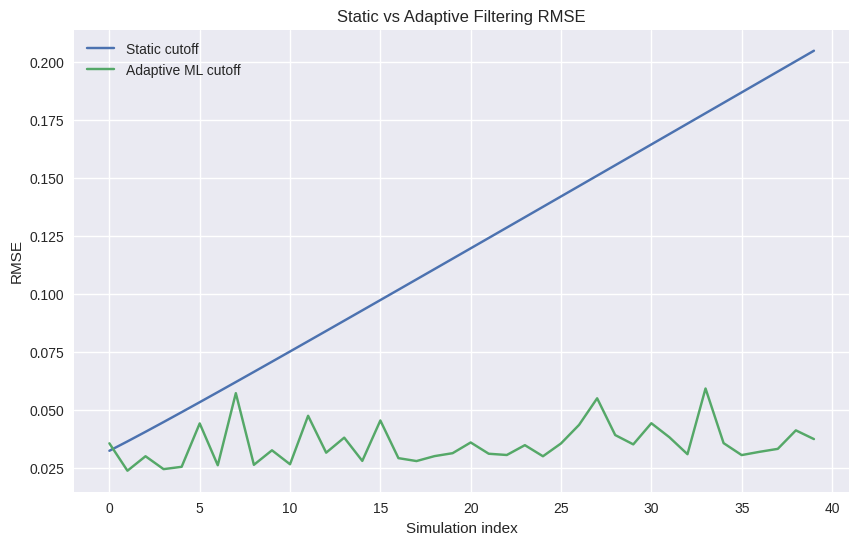

In [59]:
"""
Main evaluation figure
"""

plt.figure(figsize=(10,6))

plt.plot(
    rmse_static_list,
    label="Static cutoff"
)

plt.plot(
    rmse_ml_list,
    label="Adaptive ML cutoff"
)

plt.legend()

plt.title("Static vs Adaptive Filtering RMSE")

plt.xlabel("Simulation index")

plt.ylabel("RMSE")

plt.show()

In [60]:
"""
Statistical comparison
"""

mean_static = np.mean(rmse_static_list)

mean_ml = np.mean(rmse_ml_list)


improvement_percent = (

    (mean_static - mean_ml)
    /
    mean_static
) * 100


print("Static RMSE:", mean_static)

print("ML RMSE:", mean_ml)

print("Improvement (%):", improvement_percent)

Static RMSE: 0.11755271887246095
ML RMSE: 0.03521176000213445
Improvement (%): 70.04598418490217


In [61]:
"""
Check statistical significance
"""

t_stat, p_value = ttest_rel(

    rmse_static_list,
    rmse_ml_list
)


print("t-statistic:", t_stat)

print("p-value:", p_value)

t-statistic: 10.364005612220424
p-value: 9.206539204172839e-13


/tmp/ipykernel_5883/1202721918.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


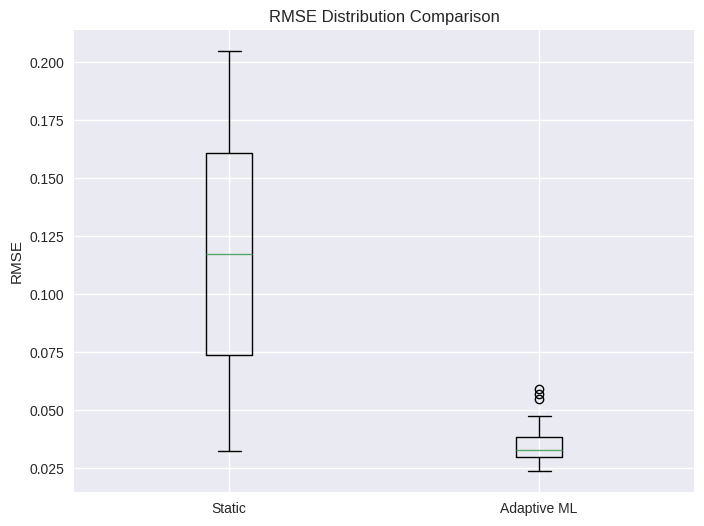

In [62]:
"""
Distribution comparison
"""

plt.figure(figsize=(8,6))


plt.boxplot(

    [rmse_static_list, rmse_ml_list],

    labels=["Static", "Adaptive ML"]

)


plt.ylabel("RMSE")

plt.title("RMSE Distribution Comparison")

plt.show()

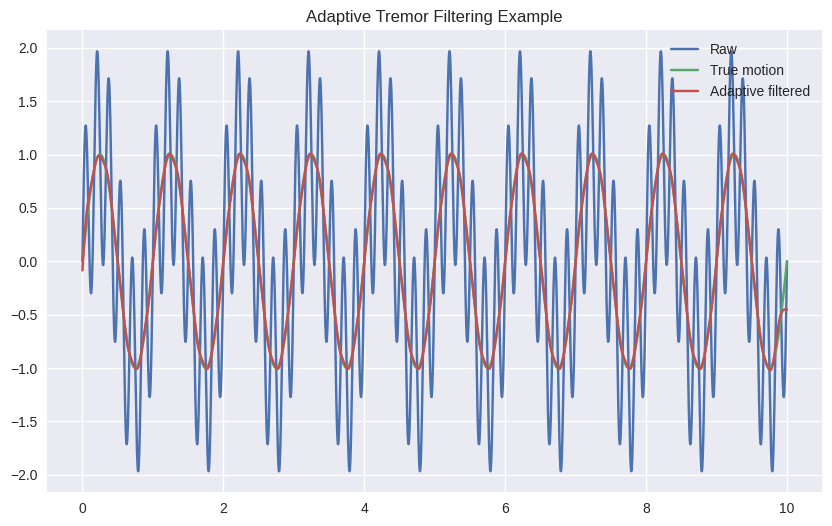

In [63]:
"""
Example signal comparison
"""

severity = 1.0


intended_motion = np.sin(2*np.pi*1*t)


tremor = severity * np.sin(2*np.pi*6*t)


raw_signal = intended_motion + tremor


predicted_cutoff = model.predict(
    [[severity]]
)[0]


filtered_signal = apply_lowpass(
    raw_signal,
    predicted_cutoff
)


plt.figure(figsize=(10,6))

plt.plot(t, raw_signal, label="Raw")

plt.plot(t, intended_motion, label="True motion")

plt.plot(t, filtered_signal, label="Adaptive filtered")

plt.legend()

plt.title("Adaptive Tremor Filtering Example")

plt.show()

In [64]:
"""
Close database safely
"""

conn.close()

print("Database closed")

Database closed
